## Exercise 2

# 2.1

For the output to be a probability distribution, we define the Neural Network to have a softmax activation function in the output layer. This ensures that the output values are between 0 and 1 and that they sum up to 1, making them valid probabilities. At least this is a useful way to interpret the output of the Neural Network as a probability distribution over the classes, but i cannot remember if this was the way we did it in the lecture.

# 2.2

## Part 2

# 1.1
This task is most naturally described as continuing since there is no natural end to the task. There is not defined a terminal state, and we are told that a new cookie falls immediately after the previous one is collected or has disappeared. Therefore, the agent is expected to maximize the reward over an infinite horizon.

# 1.2
We need a linear approximation for the state-action value function since the state space is continuous.

Q(s, a) = w_a^T * φ(s, a) 

where w_a is a weight vector for action a and φ(s, a) is a feature vector that represents the state-action pair (s, a).

the states are defined as:
-c: position of the cookie
-x: position of the robot
-v: velocity of the robot
-tau: time until the cookie disappears

actions are defined as:
A = {-5, 0, 5} (decrease velocity by 5, keep velocity, increase velocity by 5)
We should feature engineer the states so that they are more informative for the rewards. I can for example create features such as:

- d = c - x (signed distance between the cookie and the robot)
- d * v (distance multiplied by velocity, which can indicate how quickly the robot is approaching the cookie. This is useful because if the robot is moving too fast it cannot pick up the cookie and gets a negative reward)
- x (position of the robot relative to the left wall)
- y = 10 -x (position of the robot relative to the right wall)
- tau (time until the cookie disappears)
then we can define the feature vector as:
φ(s) = [1,d, |d|, d * v, x, v, $$\tau$$]
where the first element is a bias term.

update rule for the weights w_a is under Q:
w_a = w_a + α * (r + γ * max_{a'} Q(s', a') - Q(s, a)) * φ(s)






In [5]:
# Implementation of Q-learning with linear function approximation
import numpy as np
import gymnasium
import cookiedisaster

env = gymnasium.make("cookiedisaster/GridWorld-v0", disable_env_checker=True)

def feature_vector(s):
    c = s["cookie"]["pos"]
    x = s["agent"]["pos"]
    v = s["agent"]["vel"]
    tau = s["cookie"]["time"]

    d = c - x
    return np.array([
        1.0,
        d / 10.0,
        abs(d) / 10.0,
        v / 5.0,
        tau / 5.0,
        (d * v) / 50.0,
        x / 10.0,
    ], dtype=float)

def epsilon_greedy_action(w, phi, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(w.shape[0])
    q_values = w @ phi
    return int(np.argmax(q_values))

def q_learning_with_linear_approximation(alpha=0.05, gamma=0.99, epsilon=0.1, num_episodes=500, max_steps=200):
    n_actions = env.action_space.n
    n_features = len(feature_vector(env.reset()[0]))
    w = np.zeros((n_actions, n_features), dtype=float)
    episode_returns = []

    for episode in range(num_episodes):
        s, _ = env.reset()
        total_reward = 0.0

        for t in range(max_steps):
            phi = feature_vector(s)
            a = epsilon_greedy_action(w, phi, epsilon)

            s_next, r, terminated, truncated, _ = env.step(a)
            phi_next = feature_vector(s_next)

            if terminated or truncated:
                td_target = r
            else:
                td_target = r + gamma * np.max(w @ phi_next)

            td_error = td_target - np.dot(w[a], phi)
            w[a] += alpha * td_error * phi

            s = s_next
            total_reward += r
            total_reward += r

            if terminated or truncated:
                break

        episode_returns.append(total_reward)

    return w, episode_returns

linear_weights, linear_returns = q_learning_with_linear_approximation()
weights, returns = linear_weights, linear_returns
print("Learned weight matrix shape:", linear_weights.shape)
print("Average return over last 50 episodes:", np.mean(linear_returns[-50:]))


/opt/miniconda3/envs/gymenv/lib/python3.10/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/opt/miniconda3/envs/gymenv/lib/python3.10/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Learned weight matrix shape: (3, 7)
Average return over last 50 episodes: 4.698908827243679


In [6]:
# Neural-network approximation of Q(s, a)
import torch
import torch.nn as nn
import torch.optim as optim

def feature_vector_nn(s):
    c = s["cookie"]["pos"]
    x = s["agent"]["pos"]
    v = s["agent"]["vel"]
    tau = s["cookie"]["time"]

    d = c - x
    return np.array([
        d / 10.0,
        abs(d) / 10.0,
        v / 5.0,
        tau / 5.0,
        x / 10.0,
        (d * v) / 50.0,
    ], dtype=np.float32)

class QNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, n_actions=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_actions),
        )

    def forward(self, x):
        return self.net(x)

def epsilon_greedy_action_nn(q_net, phi, epsilon):
    if np.random.rand() < epsilon:
        return env.action_space.sample()
    with torch.no_grad():
        phi_tensor = torch.tensor(phi.tolist(), dtype=torch.float32).unsqueeze(0)
        q_values = q_net(phi_tensor)
        return int(torch.argmax(q_values, dim=1).item())

def q_learning_with_nn(alpha=1e-3, gamma=0.99, epsilon=0.1, num_episodes=500, max_steps=200):
    input_dim = len(feature_vector_nn(env.reset()[0]))
    n_actions = env.action_space.n

    q_net = QNetwork(input_dim=input_dim, hidden_dim=32, n_actions=n_actions)
    optimizer = optim.Adam(q_net.parameters(), lr=alpha)
    loss_fn = nn.SmoothL1Loss()
    episode_returns = []

    for episode in range(num_episodes):
        s, _ = env.reset()
        total_reward = 0.0

        for t in range(max_steps):
            phi = feature_vector_nn(s)
            a = epsilon_greedy_action_nn(q_net, phi, epsilon)

            s_next, r, terminated, truncated, _ = env.step(a)
            phi_next = feature_vector_nn(s_next)

            phi_tensor = torch.tensor(phi.tolist(), dtype=torch.float32).unsqueeze(0)
            q_values = q_net(phi_tensor)
            q_sa = q_values[0, a]

            with torch.no_grad():
                phi_next_tensor = torch.tensor(phi_next.tolist(), dtype=torch.float32).unsqueeze(0)
                q_next = q_net(phi_next_tensor)
                if terminated or truncated:
                    target = torch.tensor(r, dtype=torch.float32)
                else:
                    target = torch.tensor(r, dtype=torch.float32) + gamma * torch.max(q_next)

            loss = loss_fn(q_sa, target)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            s = s_next
            total_reward += r

            if terminated or truncated:
                break

        episode_returns.append(total_reward)

    return q_net, episode_returns

q_net, nn_returns = q_learning_with_nn()
print("Average NN return over last 50 episodes:", np.mean(nn_returns[-50:]))


Average NN return over last 50 episodes: 11.7167707121374


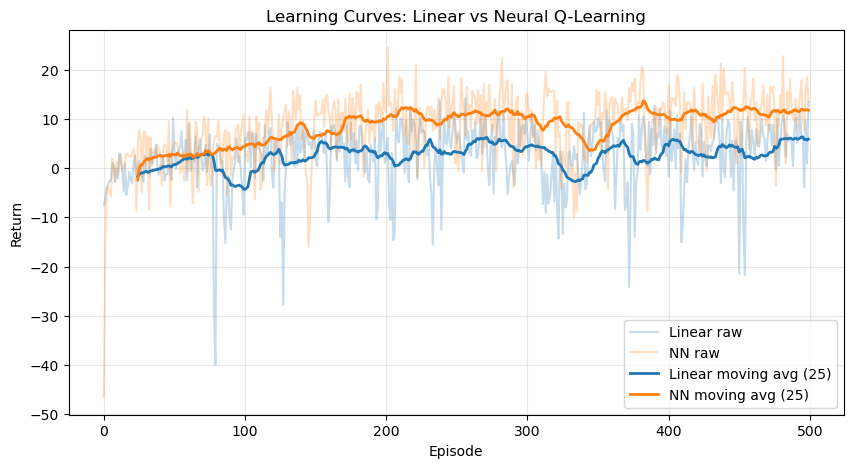

/var/folders/96/1lnlvkys5fj7y7st7rzx35p00000gp/T/ipykernel_60878/60665679.py:75: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


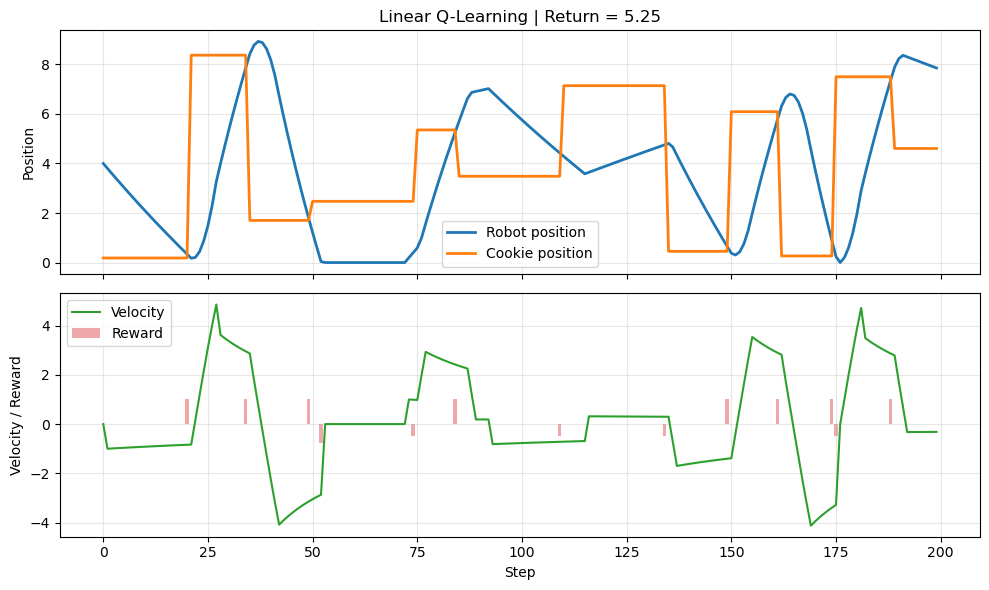

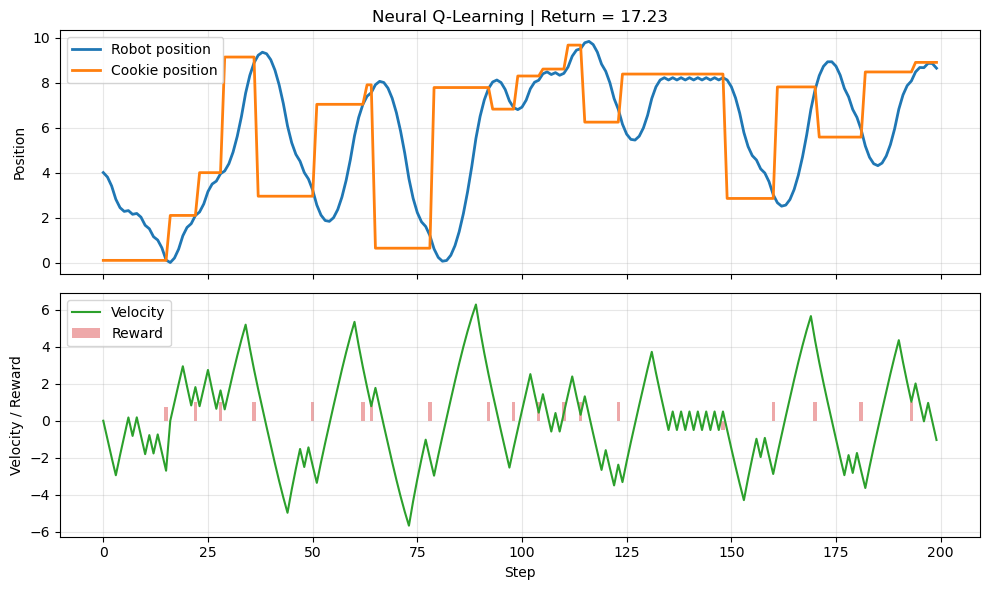

Linear policy:
Mean return over 20 eval episodes: 3.263
Std return over 20 eval episodes:  2.721
Min / Max return: -2.127 / 9.318

Neural policy:
Mean return over 20 eval episodes: 18.534
Std return over 20 eval episodes:  2.593
Min / Max return: 12.384 / 23.224


In [7]:
# Comparison plots and greedy-policy evaluation
import matplotlib.pyplot as plt

def moving_average(x, window=25):
    x = np.asarray(x, dtype=float)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window) / window, mode="valid")

def plot_learning_curves(linear_returns, nn_returns, window=25):
    plt.figure(figsize=(10, 5))
    plt.plot(linear_returns, alpha=0.25, label="Linear raw", color="tab:blue")
    plt.plot(nn_returns, alpha=0.25, label="NN raw", color="tab:orange")
    plt.plot(range(window - 1, len(linear_returns)), moving_average(linear_returns, window), label=f"Linear moving avg ({window})", color="tab:blue", linewidth=2)
    plt.plot(range(window - 1, len(nn_returns)), moving_average(nn_returns, window), label=f"NN moving avg ({window})", color="tab:orange", linewidth=2)
    plt.xlabel("Episode")
    plt.ylabel("Return")
    plt.title("Learning Curves: Linear vs Neural Q-Learning")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def linear_greedy_action(weights, s):
    phi = feature_vector(s)
    q_values = weights @ phi
    return int(np.argmax(q_values))

def nn_greedy_action(q_net, s):
    phi = feature_vector_nn(s)
    phi_tensor = torch.tensor(phi.tolist(), dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        q_values = q_net(phi_tensor)
    return int(torch.argmax(q_values, dim=1).item())

def rollout(policy_fn, max_steps=200):
    eval_env = gymnasium.make("cookiedisaster/GridWorld-v0", disable_env_checker=True)
    s, _ = eval_env.reset()
    traj = {"robot_x": [], "cookie_x": [], "velocity": [], "reward": []}
    total_return = 0.0

    for _ in range(max_steps):
        traj["robot_x"].append(s["agent"]["pos"])
        traj["cookie_x"].append(s["cookie"]["pos"])
        traj["velocity"].append(s["agent"]["vel"])

        a = policy_fn(s)
        s, r, terminated, truncated, _ = eval_env.step(a)
        traj["reward"].append(r)
        total_return += r

        if terminated or truncated:
            break

    eval_env.close()
    traj["total_return"] = total_return
    return traj

def plot_rollout(traj, title):
    t = np.arange(len(traj["robot_x"]))
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    axes[0].plot(t, traj["robot_x"], label="Robot position", linewidth=2)
    axes[0].plot(t, traj["cookie_x"], label="Cookie position", linewidth=2)
    axes[0].set_ylabel("Position")
    axes[0].set_title(f"{title} | Return = {traj['total_return']:.2f}")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(t, traj["velocity"], label="Velocity", color="tab:green")
    axes[1].bar(t, traj["reward"], alpha=0.4, label="Reward", color="tab:red")
    axes[1].set_xlabel("Step")
    axes[1].set_ylabel("Velocity / Reward")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def evaluate_policy(policy_fn, n_episodes=20, max_steps=200):
    eval_returns = []
    for _ in range(n_episodes):
        traj = rollout(policy_fn, max_steps=max_steps)
        eval_returns.append(traj["total_return"])
    eval_returns = np.asarray(eval_returns, dtype=float)
    print(f"Mean return over {n_episodes} eval episodes: {eval_returns.mean():.3f}")
    print(f"Std return over {n_episodes} eval episodes:  {eval_returns.std():.3f}")
    print(f"Min / Max return: {eval_returns.min():.3f} / {eval_returns.max():.3f}")

plot_learning_curves(linear_returns, nn_returns, window=25)

linear_traj = rollout(lambda s: linear_greedy_action(linear_weights, s))
nn_traj = rollout(lambda s: nn_greedy_action(q_net, s))
plot_rollout(linear_traj, "Linear Q-Learning")
plot_rollout(nn_traj, "Neural Q-Learning")

print("Linear policy:")
evaluate_policy(lambda s: linear_greedy_action(linear_weights, s))
print("\nNeural policy:")
evaluate_policy(lambda s: nn_greedy_action(q_net, s))


The difference between linear and nn function approximation is that the linear function approximation assumes that the relationship between the engineered features and the q-values are linear, while the NN function approximation can learn non-linear relationships between the raw state inputs and the q-values. Hence, the linear function is dependent on good engineered features to capture the relevant information, while the NN can learn to extract the relevant features from the raw state inputs.

As we see from the results, the NN method performs significantly better, which suggests that it has been able to capture more relevant information than what the linear method could with our engineered features. However, NN also used significantly more computational resources.

## 5.5

For 5.5 I have decided to implement a simple on-policy actor-critic model.

In [12]:
def feature_vector_ac(s):
    c = s["cookie"]["pos"]
    x = s["agent"]["pos"]
    v = s["agent"]["vel"]
    tau = s["cookie"]["time"]

    d = c - x
    return np.array([
        d / 10.0,
        abs(d) / 10.0,
        v / 5.0,
        tau / 5.0,
        x / 10.0,
        (d * v) / 50.0,
    ], dtype=np.float32)


class ActorCriticNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, n_actions=3):
        super().__init__()
        
        self.shared = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.actor_head = nn.Linear(hidden_dim, n_actions)
        self.critic_head = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        h = self.shared(x)
        logits = self.actor_head(h)
        value = self.critic_head(h)
        return logits, value
    
def actor_critic_train(alpha=1e-3, gamma=0.99, num_episodes=500, max_steps=200):
    input_dim = len(feature_vector_ac(env.reset()[0]))
    n_actions = env.action_space.n
    model = ActorCriticNetwork(input_dim=input_dim, hidden_dim=32, n_actions=n_actions)
    optimizer = optim.Adam(model.parameters(), lr=alpha)

    episode_returns = []

    for episode in range(num_episodes):
        s, _ = env.reset()
        total_reward = 0.0

        for t in range(max_steps):
            phi = feature_vector_ac(s)
            phi_tensor = torch.tensor(phi.tolist(), dtype=torch.float32).unsqueeze(0)

            logits, value = model(phi_tensor)

            dist = Categorical(logits=logits) # Create a categorical distribution over actions
            action = dist.sample() # Sample an action from the distribution
            log_prob = dist.log_prob(action) # Get the log probability of the action

            s_next, r, terminated, truncated, _ = env.step(action.item())
            total_reward += r

            phi_next = feature_vector_ac(s_next)
            phi_next_tensor = torch.tensor(phi_next.tolist(), dtype=torch.float32).unsqueeze(0)
            
            with torch.no_grad():
                _, next_value = model(phi_next_tensor)
                if terminated or truncated:
                    target = torch.tensor(r, dtype=torch.float32)
                else:
                    target = torch.tensor(r, dtype=torch.float32) + gamma * next_value
            
            delta = target - value

            actor_loss = -log_prob * delta.detach().squeeze() # Actor loss (policy gradient)
            critic_loss = delta.pow(2).mean() # Critic loss (value function regression)
            loss = actor_loss + critic_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            s = s_next

            if terminated or truncated:
                break

        episode_returns.append(total_reward)
    
    return model, episode_returns

ac_model, ac_returns = actor_critic_train()
print("Average actor-critic return over last 50 episodes:", np.mean(ac_returns[-50:]))




Average actor-critic return over last 50 episodes: 22.69180834618445


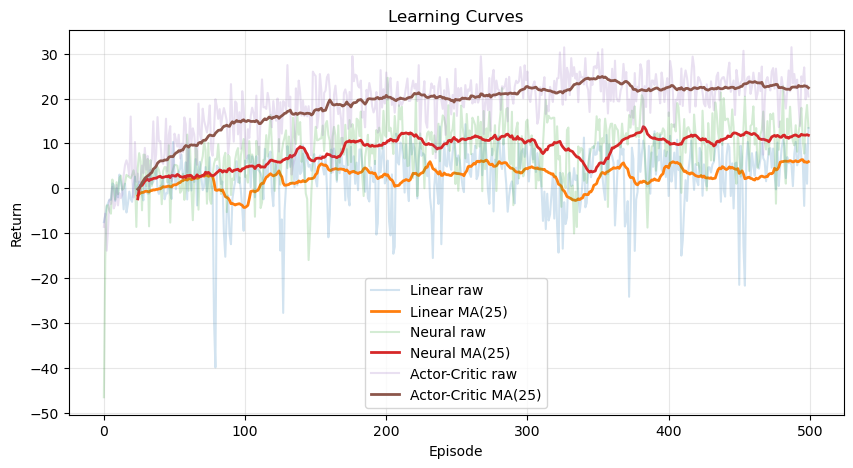

/opt/miniconda3/envs/gymenv/lib/python3.10/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/opt/miniconda3/envs/gymenv/lib/python3.10/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Linear:
  Mean return: 3.614
  Std return:  2.218
  Min return:  -3.829
  Max return:  6.643

Neural:
  Mean return: 17.900
  Std return:  2.294
  Min return:  13.234
  Max return:  22.461

Actor-Critic:
  Mean return: 24.862
  Std return:  2.273
  Min return:  21.000
  Max return:  28.970



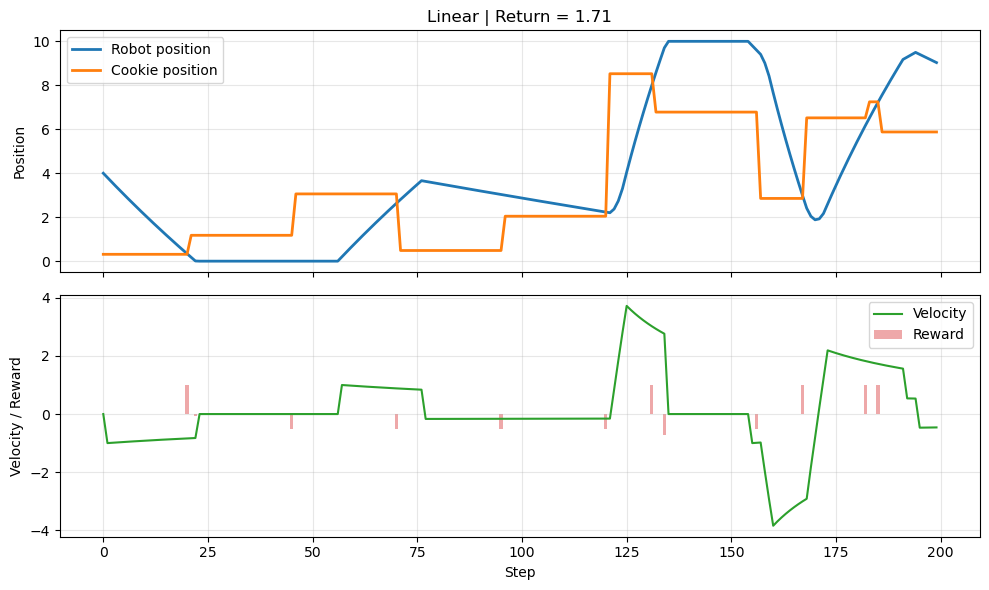

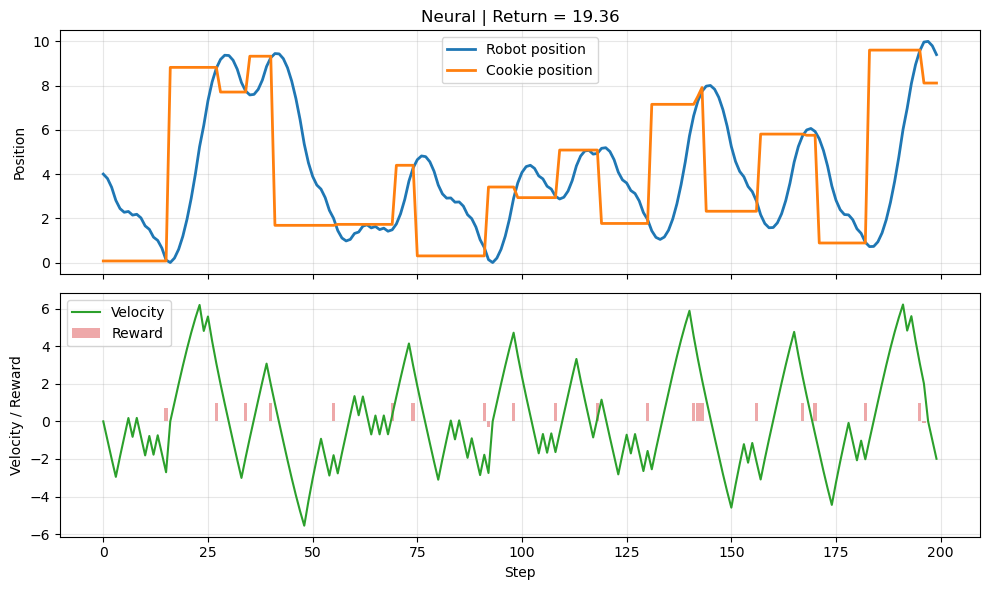

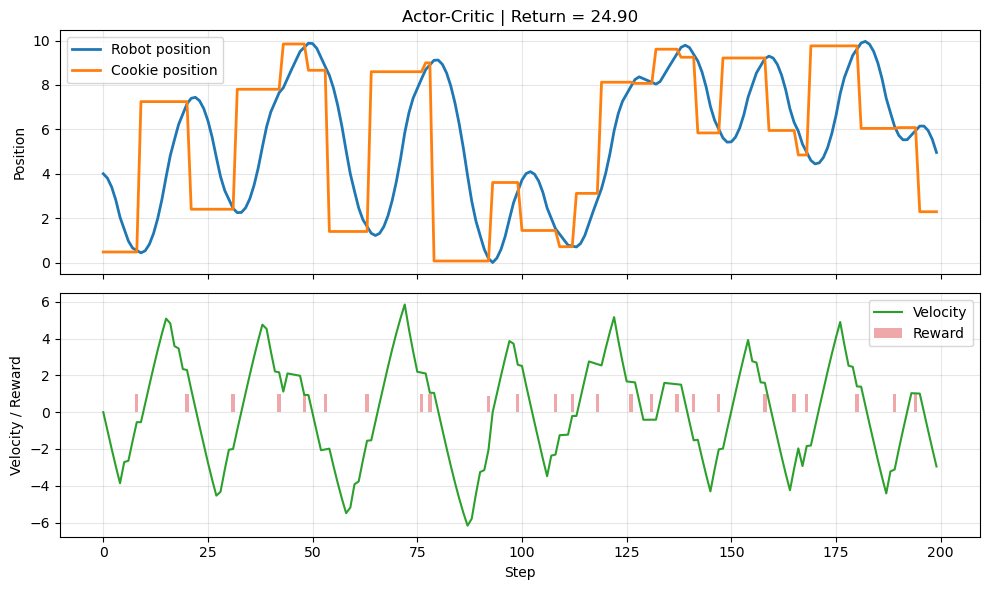

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.distributions import Categorical
import gymnasium
import cookiedisaster

ENV_ID = "cookiedisaster/GridWorld-v0"


def moving_average(x, window=25):
    x = np.asarray(x, dtype=float)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window) / window, mode="valid")


def linear_greedy_action(weights, s):
    phi = feature_vector(s)
    q_values = weights @ phi
    return int(np.argmax(q_values))


def nn_greedy_action(q_net, s):
    phi = feature_vector_nn(s)
    phi_tensor = torch.tensor(phi.tolist(), dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        q_values = q_net(phi_tensor)
    return int(torch.argmax(q_values, dim=1).item())


def actor_critic_action(ac_model, s, stochastic=False):
    phi = feature_vector_ac(s) 
    phi_tensor = torch.tensor(phi.tolist(), dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        logits, value = ac_model(phi_tensor)

    if stochastic:
        dist = Categorical(logits=logits)
        return int(dist.sample().item())

    return int(torch.argmax(logits, dim=1).item())


def rollout(policy_fn, max_steps=200):
    env = gymnasium.make(ENV_ID, disable_env_checker=True)
    s, _ = env.reset()

    traj = {
        "robot_x": [],
        "cookie_x": [],
        "velocity": [],
        "tau": [],
        "reward": [],
        "action": [],
    }

    total_return = 0.0

    for _ in range(max_steps):
        traj["robot_x"].append(s["agent"]["pos"])
        traj["cookie_x"].append(s["cookie"]["pos"])
        traj["velocity"].append(s["agent"]["vel"])
        traj["tau"].append(s["cookie"]["time"])

        a = policy_fn(s)
        s, r, terminated, truncated, _ = env.step(a)

        traj["reward"].append(r)
        traj["action"].append(a)
        total_return += r

        if terminated or truncated:
            break

    env.close()
    traj["total_return"] = total_return
    return traj


def evaluate_policy(policy_fn, n_episodes=20, max_steps=200):
    returns = []
    for _ in range(n_episodes):
        traj = rollout(policy_fn, max_steps=max_steps)
        returns.append(traj["total_return"])

    returns = np.asarray(returns, dtype=float)
    return {
        "mean": returns.mean(),
        "std": returns.std(),
        "min": returns.min(),
        "max": returns.max(),
    }


def plot_learning_curves(model_returns, window=25):
    plt.figure(figsize=(10, 5))

    for name, returns in model_returns.items():
        plt.plot(returns, alpha=0.2, label=f"{name} raw")
        ma = moving_average(returns, window)
        if len(returns) >= window:
            plt.plot(range(window - 1, len(returns)), ma, linewidth=2, label=f"{name} MA({window})")
        else:
            plt.plot(ma, linewidth=2, label=f"{name}")

    plt.xlabel("Episode")
    plt.ylabel("Return")
    plt.title("Learning Curves")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


def plot_rollout(traj, title):
    t = np.arange(len(traj["robot_x"]))

    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    axes[0].plot(t, traj["robot_x"], label="Robot position", linewidth=2)
    axes[0].plot(t, traj["cookie_x"], label="Cookie position", linewidth=2)
    axes[0].set_ylabel("Position")
    axes[0].set_title(f"{title} | Return = {traj['total_return']:.2f}")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(t, traj["velocity"], label="Velocity", color="tab:green")
    axes[1].bar(t, traj["reward"], label="Reward", alpha=0.4, color="tab:red")
    axes[1].set_xlabel("Step")
    axes[1].set_ylabel("Velocity / Reward")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def print_summary(name, stats):
    print(f"{name}:")
    print(f"  Mean return: {stats['mean']:.3f}")
    print(f"  Std return:  {stats['std']:.3f}")
    print(f"  Min return:  {stats['min']:.3f}")
    print(f"  Max return:  {stats['max']:.3f}")
    print()


# -------------------------
# Set up the models you have
# -------------------------

model_returns = {
    "Linear": linear_returns,
    "Neural": nn_returns,
    "Actor-Critic": ac_returns,   # uncomment when you have this
}

policies = {
    "Linear": lambda s: linear_greedy_action(linear_weights, s),
    "Neural": lambda s: nn_greedy_action(q_net, s),
    "Actor-Critic": lambda s: actor_critic_action(ac_model, s, stochastic=False),
}

# -------------------------
# 1. Learning curves
# -------------------------

plot_learning_curves(model_returns, window=25)

# -------------------------
# 2. Evaluation summary
# -------------------------

for name, policy_fn in policies.items():
    stats = evaluate_policy(policy_fn, n_episodes=20, max_steps=200)
    print_summary(name, stats)

# -------------------------
# 3. One rollout per model
# -------------------------

for name, policy_fn in policies.items():
    traj = rollout(policy_fn, max_steps=200)
    plot_rollout(traj, name)
